In [ ]:
import pandas as pd
import pytz
from datetime import datetime



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
import re

In [ ]:
df = pd.read_excel('/content/already_dataset_of_dookki.xlsx')

In [ ]:
df

,media/0/thumbnail,media/0/thumbnailImage/uri,media/0/unsupported_browser_message,media/0/url,media/0/videoId,media/0/video_anchor_tag_info,media/0/video_collaborator_page_or_delegate_page,media/0/video_container_type,media/0/video_player_scrubber_preview_renderer/__module_component_VideoPlayerScrubberPreview_video/__dr,media/0/video_player_scrubber_preview_renderer/__module_operation_VideoPlayerScrubberPreview_video/__dr,...,isVideo,time,facebookId,likes,timestamp,pageAdLibrary/id,pageAdLibrary/is_business_page_active,postId,inputUrl,facebookUrl
0,NaN,NaN,NaN,https://www.facebook.com/DookkiVietnam/posts/p...,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,2025-02-03T09:35:11.000Z,100082839990680,162,1738575311,2118707468399376,False,605652452206083,https://www.facebook.com/DookkiVietnam,https://www.facebook.com/DookkiVietnam
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,2025-02-03T04:04:33.000Z,100082839990680,284,1738555473,2118707468399376,False,605507798887215,https://www.facebook.com/DookkiVietnam,https://www.facebook.com/DookkiVietnam
2,NaN,NaN,NaN,https://www.facebook.com/DookkiVietnam/posts/p...,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,2025-02-02T04:08:35.000Z,100082839990680,174,1738469315,2118707468399376,False,604799018958093,https://www.facebook.com/DookkiVietnam,https://www.facebook.com/DookkiVietnam
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,2025-02-01T03:53:29.000Z,100082839990680,632,1738382009,2118707468399376,False,604089722362356,https://www.facebook.com/DookkiVietnam,https://www.facebook.com/DookkiVietnam
4,https://scontent.fsyd10-2.fna.fbcdn.net/v/t39....,NaN,NaN,https://www.facebook.com/photo/?fbid=603583225...,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,2025-01-31T11:14:56.000Z,100082839990680,120,1738322096,2118707468399376,False,603583462412982,https://www.facebook.com/DookkiVietnam,https://www.facebook.com/DookkiVietnam
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2791,NaN,NaN,NaN,https://www.facebook.com/DookkiVietnam/posts/2...,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,2018-11-07T02:27:12.000Z,100082839990680,9,1541557632,2118707468399376,False,2240015852935203,https://www.facebook.com/DookkiVietnam,https://www.facebook.com/DookkiVietnam
2792,https://scontent.fdel25-4.fna.fbcdn.net/v/t15....,https://scontent.fdel25-4.fna.fbcdn.net/v/t15....,NaN,https://www.facebook.com/DookkiVietnam/videos/...,2.119234e+15,NaN,NaN,LEGACY,VideoPlayerScrubberDefaultPreview.react,VideoPlayerScrubberDefaultPreview_video$normal...,...,True,2018-06-07T08:29:49.000Z,100082839990680,7,1528360189,2118707468399376,False,2119234075013382,https://www.facebook.com/DookkiVietnam,https://www.facebook.com/DookkiVietnam
2793,https://scontent.fmad7-1.fna.fbcdn.net/v/t15.5...,https://scontent.fmad7-1.fna.fbcdn.net/v/t15.5...,NaN,https://www.facebook.com/DookkiVietnam/videos/...,2.119223e+15,NaN,NaN,LEGACY,VideoPlayerScrubberDefaultPreview.react,VideoPlayerScrubberDefaultPreview_video$normal...,...,True,2018-06-07T08:00:55.000Z,100082839990680,5,1528358455,2118707468399376,False,2119222505014539,https://www.facebook.com/DookkiVietnam,https://www.facebook.com/DookkiVietnam
2794,https://scontent.fmad7-1.fna.fbcdn.net/v/t15.1...,https://scontent.fmad7-1.fna.fbcdn.net/v/t15.1...,NaN,https://www.facebook.com/DookkiVietnam/videos/...,2.119215e+15,NaN,NaN,LEGACY,VideoPlayerScrubberDefaultPreview.react,VideoPlayerScrubberDefaultPreview_video$normal...,...,True,2018-06-07T07:22:49.000Z,100082839990680,5,1528356169,2118707468399376,False,2119215165015273,https://www.facebook.com/DookkiVietnam,https://www.facebook.com/DookkiVietnam


In [ ]:
df.shape

(2796, 146)

In [ ]:
# Xác định các cột chứa thông tin hình ảnh và video
image_columns = [col for col in df.columns if "/image/uri" in col]
video_columns = [col for col in df.columns if "/videoId" in col]

# Tạo cột mới: số lượng ảnh và video trong mỗi bài đăng
df["num_images"] = df[image_columns].notna().sum(axis=1)
df["num_videos"] = df[video_columns].notna().sum(axis=1)

# Xuất ra file Excel mới nếu cần
output_path = "updated_dataset.xlsx"
df.to_excel(output_path, index=False)

# Hiển thị kết quả
print(df[["num_images", "num_videos"]].describe())

        num_images   num_videos
count  2796.000000  2796.000000
mean      2.003934     0.069385
std       2.198955     0.254153
min       0.000000     0.000000
25%       0.000000     0.000000
50%       0.000000     0.000000
75%       4.000000     0.000000
max       5.000000     1.000000


In [ ]:

# Chọn các cột cần thiết
columns_to_keep = [
    # Cột liên quan đến URL và nội dung
    "url", "text",
    *[col for col in df.columns if col.startswith("textReferences/") and col.endswith("/url")],

    # Cột liên quan đến media (hình ảnh, video)
    "media/0/url", "media/0/thumbnailImage/uri", "media/0/videoId", "media/0/video_status_type",

    # Cột liên quan đến tương tác người dùng
    "likes", "shares", "viewsCount", "comments", "topReactionsCount",

    # Cột liên quan đến người đăng và trang
    "user/id", "user/name", "user/profileUrl", "pageName",

    # Cột thời gian
    "timestamp", "time",

    # Cột liên quan đến đánh giá và phản hồi
    "feedbackId", "isVideo", "topLevelUrl",

    # Cột mới đếm số lượng hình ảnh và video
    "num_images", "num_videos"
]

# Lọc chỉ giữ lại các cột cần thiết (loại bỏ các cột không mong muốn)
df_filtered = df[columns_to_keep]

# Kiểm tra kết quả
df_filtered.head()

,url,text,textReferences/0/url,textReferences/0/web_link/url,textReferences/1/url,textReferences/2/url,textReferences/3/url,textReferences/4/url,textReferences/5/url,textReferences/6/url,...,user/name,user/profileUrl,pageName,timestamp,time,feedbackId,isVideo,topLevelUrl,num_images,num_videos
0,https://www.facebook.com/DookkiVietnam/posts/p...,NHẢ VÍA SÁNG GIỜ AI KHOE LÌ XÌ LÀ PHẢI BAO TUI...,https://www.facebook.com/hashtag/dookkivietnam...,NaN,https://www.facebook.com/hashtag/dookkibuffett...,https://www.facebook.com/hashtag/dookki?__eep__=6,https://www.facebook.com/hashtag/dookkinew?__e...,https://www.facebook.com/hashtag/139k?__eep__=6,NaN,NaN,...,Dookki Vietnam,https://www.facebook.com/DookkiVietnam,DookkiVietnam,1738575311,2025-02-03T09:35:11.000Z,ZmVlZGJhY2s6NjA1NjUyNDUyMjA2MDgz,NaN,https://www.facebook.com/100082839990680/posts...,5,0
1,https://www.facebook.com/DookkiVietnam/posts/p...,ĐÃ ĐẾN LÚC LÊN KÈO DOOKKI RỒI FEN ƠI VÌ TOÀN B...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Dookki Vietnam,https://www.facebook.com/DookkiVietnam,DookkiVietnam,1738555473,2025-02-03T04:04:33.000Z,ZmVlZGJhY2s6NjA1NTA3Nzk4ODg3MjE1,NaN,https://www.facebook.com/100082839990680/posts...,0,0
2,https://www.facebook.com/DookkiVietnam/posts/p...,NÓNG \nPhát hiện nhiều Fen vội vàng đi ăn Dook...,https://www.facebook.com/hashtag/139k?__eep__=6,NaN,https://www.facebook.com/hashtag/dookkivietnam...,https://www.facebook.com/hashtag/dookkibuffett...,https://www.facebook.com/hashtag/dookki?__eep__=6,https://www.facebook.com/hashtag/dookkinew?__e...,https://www.facebook.com/hashtag/139k?__eep__=6,NaN,...,Dookki Vietnam,https://www.facebook.com/DookkiVietnam,DookkiVietnam,1738469315,2025-02-02T04:08:35.000Z,ZmVlZGJhY2s6NjA0Nzk5MDE4OTU4MDkz,NaN,https://www.facebook.com/100082839990680/posts...,4,0
3,https://www.facebook.com/DookkiVietnam/posts/p...,Thế mí người hứa đầu năm bao tui ăn Dookki lấy...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Dookki Vietnam,https://www.facebook.com/DookkiVietnam,DookkiVietnam,1738382009,2025-02-01T03:53:29.000Z,ZmVlZGJhY2s6NjA0MDg5NzIyMzYyMzU2,NaN,https://www.facebook.com/100082839990680/posts...,0,0
4,https://www.facebook.com/DookkiVietnam/posts/p...,Mùng 1 Tết Cha - Mùng 2 Tết Mẹ - Mùng 2 Tết Th...,https://www.facebook.com/hashtag/139k?__eep__=6,NaN,https://www.facebook.com/hashtag/dookkivietnam...,https://www.facebook.com/hashtag/dookkibuffett...,https://www.facebook.com/hashtag/dookki?__eep__=6,https://www.facebook.com/hashtag/dookkinew?__e...,https://www.facebook.com/hashtag/139k?__eep__=6,NaN,...,Dookki Vietnam,https://www.facebook.com/DookkiVietnam,DookkiVietnam,1738322096,2025-01-31T11:14:56.000Z,ZmVlZGJhY2s6NjAzNTgzNDYyNDEyOTgy,NaN,https://www.facebook.com/100082839990680/posts...,0,0


In [ ]:
df_filtered.head()

,url,text,textReferences/0/url,textReferences/0/web_link/url,textReferences/1/url,textReferences/2/url,textReferences/3/url,textReferences/4/url,textReferences/5/url,textReferences/6/url,...,user/name,user/profileUrl,pageName,timestamp,time,feedbackId,isVideo,topLevelUrl,num_images,num_videos
0,https://www.facebook.com/DookkiVietnam/posts/p...,NHẢ VÍA SÁNG GIỜ AI KHOE LÌ XÌ LÀ PHẢI BAO TUI...,https://www.facebook.com/hashtag/dookkivietnam...,NaN,https://www.facebook.com/hashtag/dookkibuffett...,https://www.facebook.com/hashtag/dookki?__eep__=6,https://www.facebook.com/hashtag/dookkinew?__e...,https://www.facebook.com/hashtag/139k?__eep__=6,NaN,NaN,...,Dookki Vietnam,https://www.facebook.com/DookkiVietnam,DookkiVietnam,1738575311,2025-02-03T09:35:11.000Z,ZmVlZGJhY2s6NjA1NjUyNDUyMjA2MDgz,NaN,https://www.facebook.com/100082839990680/posts...,5,0
1,https://www.facebook.com/DookkiVietnam/posts/p...,ĐÃ ĐẾN LÚC LÊN KÈO DOOKKI RỒI FEN ƠI VÌ TOÀN B...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Dookki Vietnam,https://www.facebook.com/DookkiVietnam,DookkiVietnam,1738555473,2025-02-03T04:04:33.000Z,ZmVlZGJhY2s6NjA1NTA3Nzk4ODg3MjE1,NaN,https://www.facebook.com/100082839990680/posts...,0,0
2,https://www.facebook.com/DookkiVietnam/posts/p...,NÓNG \nPhát hiện nhiều Fen vội vàng đi ăn Dook...,https://www.facebook.com/hashtag/139k?__eep__=6,NaN,https://www.facebook.com/hashtag/dookkivietnam...,https://www.facebook.com/hashtag/dookkibuffett...,https://www.facebook.com/hashtag/dookki?__eep__=6,https://www.facebook.com/hashtag/dookkinew?__e...,https://www.facebook.com/hashtag/139k?__eep__=6,NaN,...,Dookki Vietnam,https://www.facebook.com/DookkiVietnam,DookkiVietnam,1738469315,2025-02-02T04:08:35.000Z,ZmVlZGJhY2s6NjA0Nzk5MDE4OTU4MDkz,NaN,https://www.facebook.com/100082839990680/posts...,4,0
3,https://www.facebook.com/DookkiVietnam/posts/p...,Thế mí người hứa đầu năm bao tui ăn Dookki lấy...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Dookki Vietnam,https://www.facebook.com/DookkiVietnam,DookkiVietnam,1738382009,2025-02-01T03:53:29.000Z,ZmVlZGJhY2s6NjA0MDg5NzIyMzYyMzU2,NaN,https://www.facebook.com/100082839990680/posts...,0,0
4,https://www.facebook.com/DookkiVietnam/posts/p...,Mùng 1 Tết Cha - Mùng 2 Tết Mẹ - Mùng 2 Tết Th...,https://www.facebook.com/hashtag/139k?__eep__=6,NaN,https://www.facebook.com/hashtag/dookkivietnam...,https://www.facebook.com/hashtag/dookkibuffett...,https://www.facebook.com/hashtag/dookki?__eep__=6,https://www.facebook.com/hashtag/dookkinew?__e...,https://www.facebook.com/hashtag/139k?__eep__=6,NaN,...,Dookki Vietnam,https://www.facebook.com/DookkiVietnam,DookkiVietnam,1738322096,2025-01-31T11:14:56.000Z,ZmVlZGJhY2s6NjAzNTgzNDYyNDEyOTgy,NaN,https://www.facebook.com/100082839990680/posts...,0,0


In [ ]:

print(max(df_filtered['num_images']))
print(max(df_filtered['num_videos']))

5
1


In [ ]:
df_filtered["time"] = pd.to_datetime(df_filtered["time"], errors="coerce")

# Định nghĩa múi giờ
utc_zone = pytz.utc  # UTC gốc
vn_zone = pytz.timezone("Asia/Ho_Chi_Minh")  # Múi giờ Việt Nam (UTC+7)

# Chuyển đổi sang múi giờ Việt Nam
df_filtered["time_vn"] = df_filtered["time"].dt.tz_convert(vn_zone)

# Tạo các cột ngày, thứ, tuần trong tháng, tháng, năm
df_filtered["date_vn"] = df_filtered["time_vn"].dt.date
df_filtered["day_of_week_vn"] = df_filtered["time_vn"].dt.dayofweek  # Thứ trong tuần (Monday, Tuesday,...)
df_filtered["week_of_month_vn"] = (df_filtered["time_vn"].dt.day - 1) // 7 + 1  # Tính tuần trong tháng
df_filtered["month_vn"] = df_filtered["time_vn"].dt.month
df_filtered["year_vn"] = df_filtered["time_vn"].dt.year
df_filtered["hour_vn"] = df_filtered["time_vn"].dt.hour

# Kiểm tra kết quả
print(df_filtered[["time", "time_vn", "date_vn", "day_of_week_vn", "week_of_month_vn", "month_vn", "year_vn", "hour_vn"]].head())

                       time                   time_vn     date_vn  \
0 2025-02-03 09:35:11+00:00 2025-02-03 16:35:11+07:00  2025-02-03   
1 2025-02-03 04:04:33+00:00 2025-02-03 11:04:33+07:00  2025-02-03   
2 2025-02-02 04:08:35+00:00 2025-02-02 11:08:35+07:00  2025-02-02   
3 2025-02-01 03:53:29+00:00 2025-02-01 10:53:29+07:00  2025-02-01   
4 2025-01-31 11:14:56+00:00 2025-01-31 18:14:56+07:00  2025-01-31   

   day_of_week_vn  week_of_month_vn  month_vn  year_vn  hour_vn  
0               0                 1         2     2025       16  
1               0                 1         2     2025       11  
2               6                 1         2     2025       11  
3               5                 1         2     2025       10  
4               4                 5         1     2025       18  


<ipython-input-80-2329c8e4f077>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["time"] = pd.to_datetime(df_filtered["time"], errors="coerce")
<ipython-input-80-2329c8e4f077>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["time_vn"] = df_filtered["time"].dt.tz_convert(vn_zone)
<ipython-input-80-2329c8e4f077>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the

In [ ]:
df_filtered

,url,text,textReferences/0/url,textReferences/0/web_link/url,textReferences/1/url,textReferences/2/url,textReferences/3/url,textReferences/4/url,textReferences/5/url,textReferences/6/url,...,topLevelUrl,num_images,num_videos,time_vn,date_vn,day_of_week_vn,week_of_month_vn,month_vn,year_vn,hour_vn
0,https://www.facebook.com/DookkiVietnam/posts/p...,NHẢ VÍA SÁNG GIỜ AI KHOE LÌ XÌ LÀ PHẢI BAO TUI...,https://www.facebook.com/hashtag/dookkivietnam...,NaN,https://www.facebook.com/hashtag/dookkibuffett...,https://www.facebook.com/hashtag/dookki?__eep__=6,https://www.facebook.com/hashtag/dookkinew?__e...,https://www.facebook.com/hashtag/139k?__eep__=6,NaN,NaN,...,https://www.facebook.com/100082839990680/posts...,5,0,2025-02-03 16:35:11+07:00,2025-02-03,0,1,2,2025,16
1,https://www.facebook.com/DookkiVietnam/posts/p...,ĐÃ ĐẾN LÚC LÊN KÈO DOOKKI RỒI FEN ƠI VÌ TOÀN B...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,https://www.facebook.com/100082839990680/posts...,0,0,2025-02-03 11:04:33+07:00,2025-02-03,0,1,2,2025,11
2,https://www.facebook.com/DookkiVietnam/posts/p...,NÓNG \nPhát hiện nhiều Fen vội vàng đi ăn Dook...,https://www.facebook.com/hashtag/139k?__eep__=6,NaN,https://www.facebook.com/hashtag/dookkivietnam...,https://www.facebook.com/hashtag/dookkibuffett...,https://www.facebook.com/hashtag/dookki?__eep__=6,https://www.facebook.com/hashtag/dookkinew?__e...,https://www.facebook.com/hashtag/139k?__eep__=6,NaN,...,https://www.facebook.com/100082839990680/posts...,4,0,2025-02-02 11:08:35+07:00,2025-02-02,6,1,2,2025,11
3,https://www.facebook.com/DookkiVietnam/posts/p...,Thế mí người hứa đầu năm bao tui ăn Dookki lấy...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,https://www.facebook.com/100082839990680/posts...,0,0,2025-02-01 10:53:29+07:00,2025-02-01,5,1,2,2025,10
4,https://www.facebook.com/DookkiVietnam/posts/p...,Mùng 1 Tết Cha - Mùng 2 Tết Mẹ - Mùng 2 Tết Th...,https://www.facebook.com/hashtag/139k?__eep__=6,NaN,https://www.facebook.com/hashtag/dookkivietnam...,https://www.facebook.com/hashtag/dookkibuffett...,https://www.facebook.com/hashtag/dookki?__eep__=6,https://www.facebook.com/hashtag/dookkinew?__e...,https://www.facebook.com/hashtag/139k?__eep__=6,NaN,...,https://www.facebook.com/100082839990680/posts...,0,0,2025-01-31 18:14:56+07:00,2025-01-31,4,5,1,2025,18
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2791,https://www.facebook.com/DookkiVietnam/posts/2...,BẠN GÌ ƠI ĂN BUFFET TOBOKKI ĐI NÀO !!!\nHội ...,https://www.facebook.com/DookkiVietnam,NaN,https://www.facebook.com/DookkiVietnam,NaN,NaN,NaN,NaN,NaN,...,https://www.facebook.com/100082839990680/posts...,4,0,2018-11-07 09:27:12+07:00,2018-11-07,2,1,11,2018,9
2792,https://www.facebook.com/DookkiVietnam/videos/...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,https://www.facebook.com/100082839990680/posts...,0,1,2018-06-07 15:29:49+07:00,2018-06-07,3,1,6,2018,15
2793,https://www.facebook.com/DookkiVietnam/videos/...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,https://www.facebook.com/100082839990680/posts...,0,1,2018-06-07 15:00:55+07:00,2018-06-07,3,1,6,2018,15
2794,https://www.facebook.com/DookkiVietnam/videos/...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,https://www.facebook.com/100082839990680/posts...,0,1,2018-06-07 14:22:49+07:00,2018-06-07,3,1,6,2018,14


In [ ]:
na_count = df_filtered.isna().sum()
print(na_count)

url                                 0
text                               42
textReferences/0/url              831
textReferences/0/web_link/url    2698
textReferences/1/url             1059
textReferences/2/url             1487
textReferences/3/url             1689
textReferences/4/url             1917
textReferences/5/url             2296
textReferences/6/url             2476
textReferences/7/url             2548
textReferences/8/url             2590
textReferences/9/url             2621
textReferences/10/url            2643
textReferences/11/url            2673
media/0/url                       673
media/0/thumbnailImage/uri       2602
media/0/videoId                  2602
media/0/video_status_type        2602
likes                               0
shares                              0
viewsCount                       2602
comments                           63
topReactionsCount                   0
user/id                             0
user/name                           0
user/profile

In [ ]:
null_positions = df[df['text'].isnull()].index.tolist()
print(null_positions)

[249, 814, 815, 858, 887, 1028, 1072, 1109, 1296, 1374, 1769, 1972, 1992, 2094, 2122, 2134, 2140, 2147, 2339, 2347, 2389, 2394, 2397, 2446, 2449, 2487, 2494, 2511, 2545, 2587, 2588, 2605, 2625, 2639, 2781, 2782, 2783, 2784, 2792, 2793, 2794, 2795]


In [ ]:
null_positions2 = df[df['viewsCount'].notnull()].index.tolist()
print(null_positions2)

[38, 98, 122, 134, 146, 150, 154, 161, 173, 187, 197, 203, 208, 217, 223, 230, 236, 240, 262, 272, 277, 286, 294, 317, 442, 466, 517, 535, 541, 554, 560, 602, 666, 670, 675, 690, 699, 702, 709, 747, 761, 763, 767, 769, 772, 774, 776, 777, 779, 853, 887, 921, 1028, 1038, 1039, 1135, 1206, 1219, 1246, 1251, 1261, 1262, 1287, 1290, 1316, 1356, 1369, 1393, 1413, 1414, 1454, 1464, 1479, 1490, 1512, 1523, 1532, 1563, 1597, 1630, 1631, 1641, 1642, 1660, 1662, 1684, 1698, 1700, 1712, 1713, 1721, 1722, 1726, 1727, 1739, 1774, 1800, 1806, 1814, 1825, 1828, 1873, 1874, 1884, 1904, 1909, 1930, 1932, 1956, 1959, 1974, 1990, 1997, 2001, 2004, 2012, 2020, 2030, 2043, 2048, 2070, 2079, 2110, 2114, 2164, 2188, 2196, 2197, 2217, 2220, 2222, 2223, 2224, 2229, 2232, 2233, 2238, 2246, 2269, 2272, 2278, 2286, 2302, 2335, 2336, 2340, 2352, 2370, 2377, 2408, 2437, 2471, 2479, 2482, 2529, 2544, 2560, 2562, 2601, 2611, 2628, 2643, 2651, 2655, 2656, 2671, 2707, 2710, 2716, 2720, 2726, 2729, 2732, 2734, 2735, 274

In [ ]:
null_positions3 = df[df['isVideo'].notnull()].index.tolist()
print(null_positions3)

[38, 98, 122, 134, 146, 150, 154, 161, 173, 187, 197, 203, 208, 217, 223, 230, 236, 240, 262, 272, 277, 286, 294, 317, 442, 466, 517, 535, 541, 554, 560, 602, 666, 670, 675, 690, 699, 702, 709, 747, 761, 763, 767, 769, 772, 774, 776, 777, 779, 853, 887, 921, 1028, 1038, 1039, 1135, 1206, 1219, 1246, 1251, 1261, 1262, 1287, 1290, 1316, 1356, 1369, 1393, 1413, 1414, 1454, 1464, 1479, 1490, 1512, 1523, 1532, 1563, 1597, 1630, 1631, 1641, 1642, 1660, 1662, 1684, 1698, 1700, 1712, 1713, 1721, 1722, 1726, 1727, 1739, 1774, 1800, 1806, 1814, 1825, 1828, 1873, 1874, 1884, 1904, 1909, 1930, 1932, 1956, 1959, 1974, 1990, 1997, 2001, 2004, 2012, 2020, 2030, 2043, 2048, 2070, 2079, 2110, 2114, 2164, 2188, 2196, 2197, 2217, 2220, 2222, 2223, 2224, 2229, 2232, 2233, 2238, 2246, 2269, 2272, 2278, 2286, 2302, 2335, 2336, 2340, 2352, 2370, 2377, 2408, 2437, 2471, 2479, 2482, 2529, 2544, 2560, 2562, 2601, 2611, 2628, 2643, 2651, 2655, 2656, 2671, 2707, 2710, 2716, 2720, 2726, 2729, 2732, 2734, 2735, 274

In [ ]:
null_positions_comments = df[df['comments'].isnull()].index.tolist()
print(null_positions_comments)


[56, 81, 102, 113, 143, 144, 745, 814, 951, 965, 1073, 1082, 1086, 1262, 1337, 1364, 1521, 1552, 1571, 1697, 1699, 1778, 1788, 1790, 1792, 1810, 1879, 1935, 2021, 2022, 2026, 2133, 2161, 2225, 2227, 2255, 2264, 2269, 2291, 2295, 2297, 2567, 2654, 2672, 2675, 2680, 2695, 2696, 2702, 2708, 2721, 2742, 2779, 2781, 2782, 2783, 2784, 2785, 2787, 2789, 2793, 2794, 2795]


In [ ]:
df_filtered.describe()

,media/0/videoId,likes,shares,viewsCount,comments,topReactionsCount,user/id,timestamp,num_images,num_videos,day_of_week_vn,week_of_month_vn,month_vn,year_vn,hour_vn
count,1.940000e+02,2796.000000,2796.000000,1.940000e+02,2733.000000,2796.000000,2.796000e+03,2.796000e+03,2796.000000,2796.000000,2796.000000,2796.000000,2796.000000,2796.000000,2796.000000
mean,1.370860e+15,1309.375179,44.925250,1.552438e+05,672.989755,4.617310,1.000828e+14,1.639586e+09,2.003934,0.069385,2.543276,2.694564,6.762518,2021.435980,13.893062
std,2.901145e+15,2585.304964,217.131484,3.405463e+05,1678.006463,1.701154,5.938562e+00,5.764933e+07,2.198955,0.254153,1.809710,1.272688,3.669841,1.845319,3.833896
min,1.225846e+14,0.000000,0.000000,8.030000e+02,1.000000,0.000000,1.000828e+14,1.528347e+09,0.000000,0.000000,0.000000,1.000000,1.000000,2018.000000,0.000000
25%,4.358244e+14,171.000000,3.000000,1.436750e+04,55.000000,3.000000,1.000828e+14,1.592983e+09,0.000000,0.000000,1.000000,2.000000,3.000000,2020.000000,11.000000
50%,7.473863e+14,502.000000,8.000000,3.865150e+04,210.000000,5.000000,1.000828e+14,1.635473e+09,0.000000,0.000000,2.000000,3.000000,7.000000,2021.000000,14.000000
75%,1.309990e+15,1315.500000,25.000000,1.119338e+05,617.000000,6.000000,1.000828e+14,1.690533e+09,4.000000,0.000000,4.000000,4.000000,10.000000,2023.000000,17.000000
max,2.782863e+16,50456.000000,6068.000000,2.272981e+06,39600.000000,7.000000,1.000828e+14,1.738575e+09,5.000000,1.000000,6.000000,5.000000,12.000000,2025.000000,23.000000


In [ ]:
print("\n🔹 Phân bố bài đăng theo giờ đăng:")
print(df_filtered["hour_vn"].value_counts())


🔹 Phân bố bài đăng theo giờ đăng:
hour_vn
10    409
16    377
11    376
17    275
15    261
9     225
14    193
18    152
13    126
20     77
19     76
12     67
21     65
22     39
23     31
0      18
8      14
1       6
6       3
5       3
7       3
Name: count, dtype: int64


In [ ]:
# Điền 0 vào missing data
interaction_columns = ['likes', 'shares', 'comments', 'viewsCount']
df_filtered[interaction_columns] = df_filtered[interaction_columns].fillna(0)  # Điền NA bằng 0

<ipython-input-89-3fa3459460c0>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered[interaction_columns] = df_filtered[interaction_columns].fillna(0)  # Điền NA bằng 0


In [ ]:
interaction_columns1 = ['likes', 'shares', 'comments']

In [ ]:
df_filtered[interaction_columns]

,likes,shares,comments,viewsCount
0,162,3,93.0,0.0
1,284,2,85.0,0.0
2,174,3,78.0,0.0
3,632,3,352.0,0.0
4,120,1,51.0,0.0
...,...,...,...,...
2791,9,3,4.0,0.0
2792,7,1,2.0,830.0
2793,5,1,0.0,7309.0
2794,5,1,0.0,803.0


Text(0.5, 1.0, 'Biểu đồ số lượng bài đăng theo tháng')

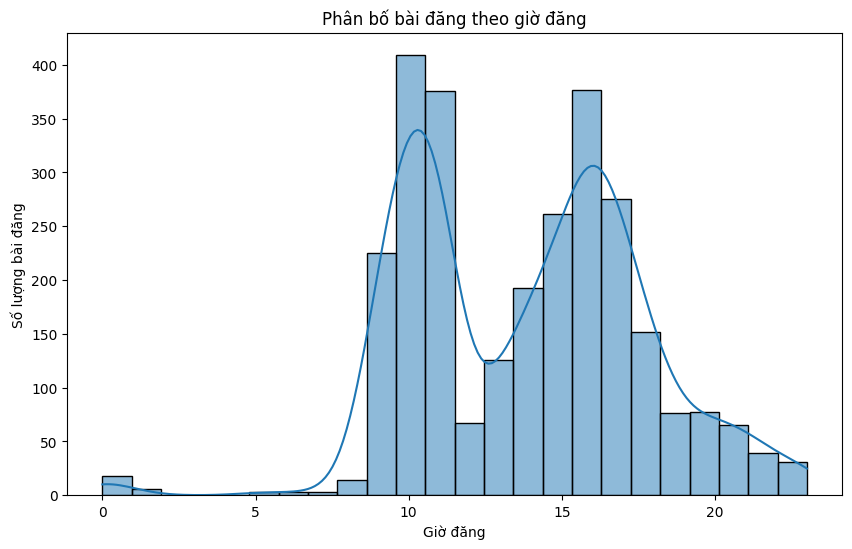

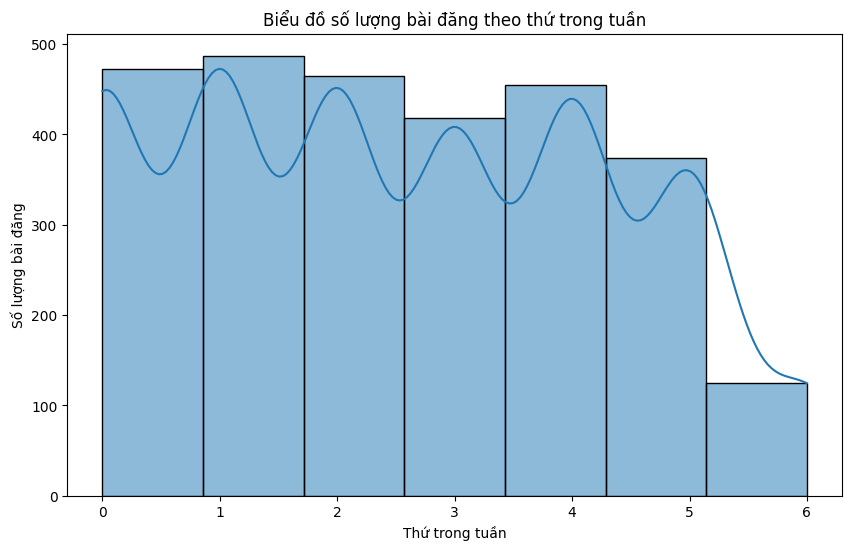

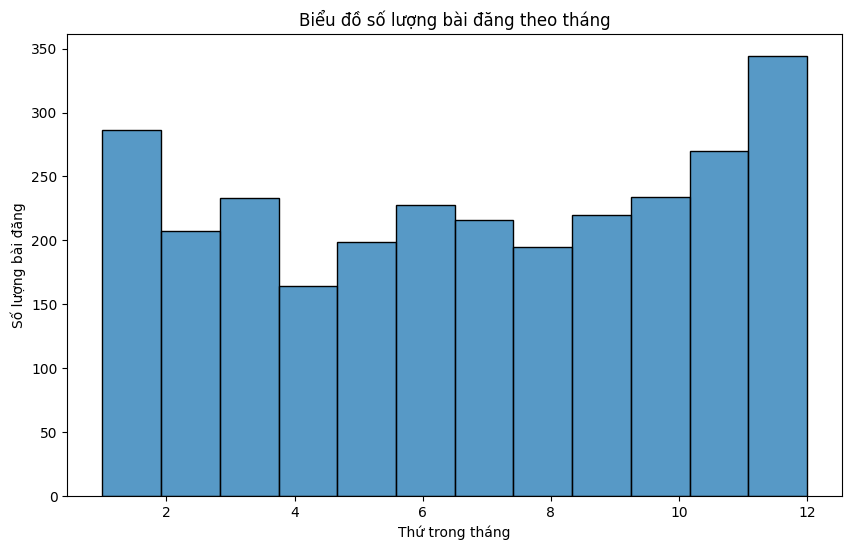

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df_filtered["hour_vn"], bins=24, kde=True)
plt.xlabel("Giờ đăng")
plt.ylabel("Số lượng bài đăng")
plt.title("Phân bố bài đăng theo giờ đăng")

plt.figure(figsize=(10, 6))
sns.histplot(df_filtered['day_of_week_vn'],bins = 7, kde=True)
plt.xlabel('Thứ trong tuần')
plt.ylabel('Số lượng bài đăng')
plt.title('Biểu đồ số lượng bài đăng theo thứ trong tuần')

plt.figure(figsize=(10, 6))
sns.histplot(df_filtered['month_vn'], bins = 12)
plt.xlabel('Thứ trong tháng')
plt.ylabel('Số lượng bài đăng')
plt.title('Biểu đồ số lượng bài đăng theo tháng')

<ipython-input-93-e0c14250d436>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_filtered.groupby('hour_vn')[interaction_columns1].sum().index,
<ipython-input-93-e0c14250d436>:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_filtered.groupby('day_of_week_vn')[interaction_columns1].sum().index,
<ipython-input-93-e0c14250d436>:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_filtered.groupby('month_vn')[interaction_columns1].sum().index,
<ipython-input-93-e0c14250d436>:31: FutureWarning: 

Passing `palette` without assigning `

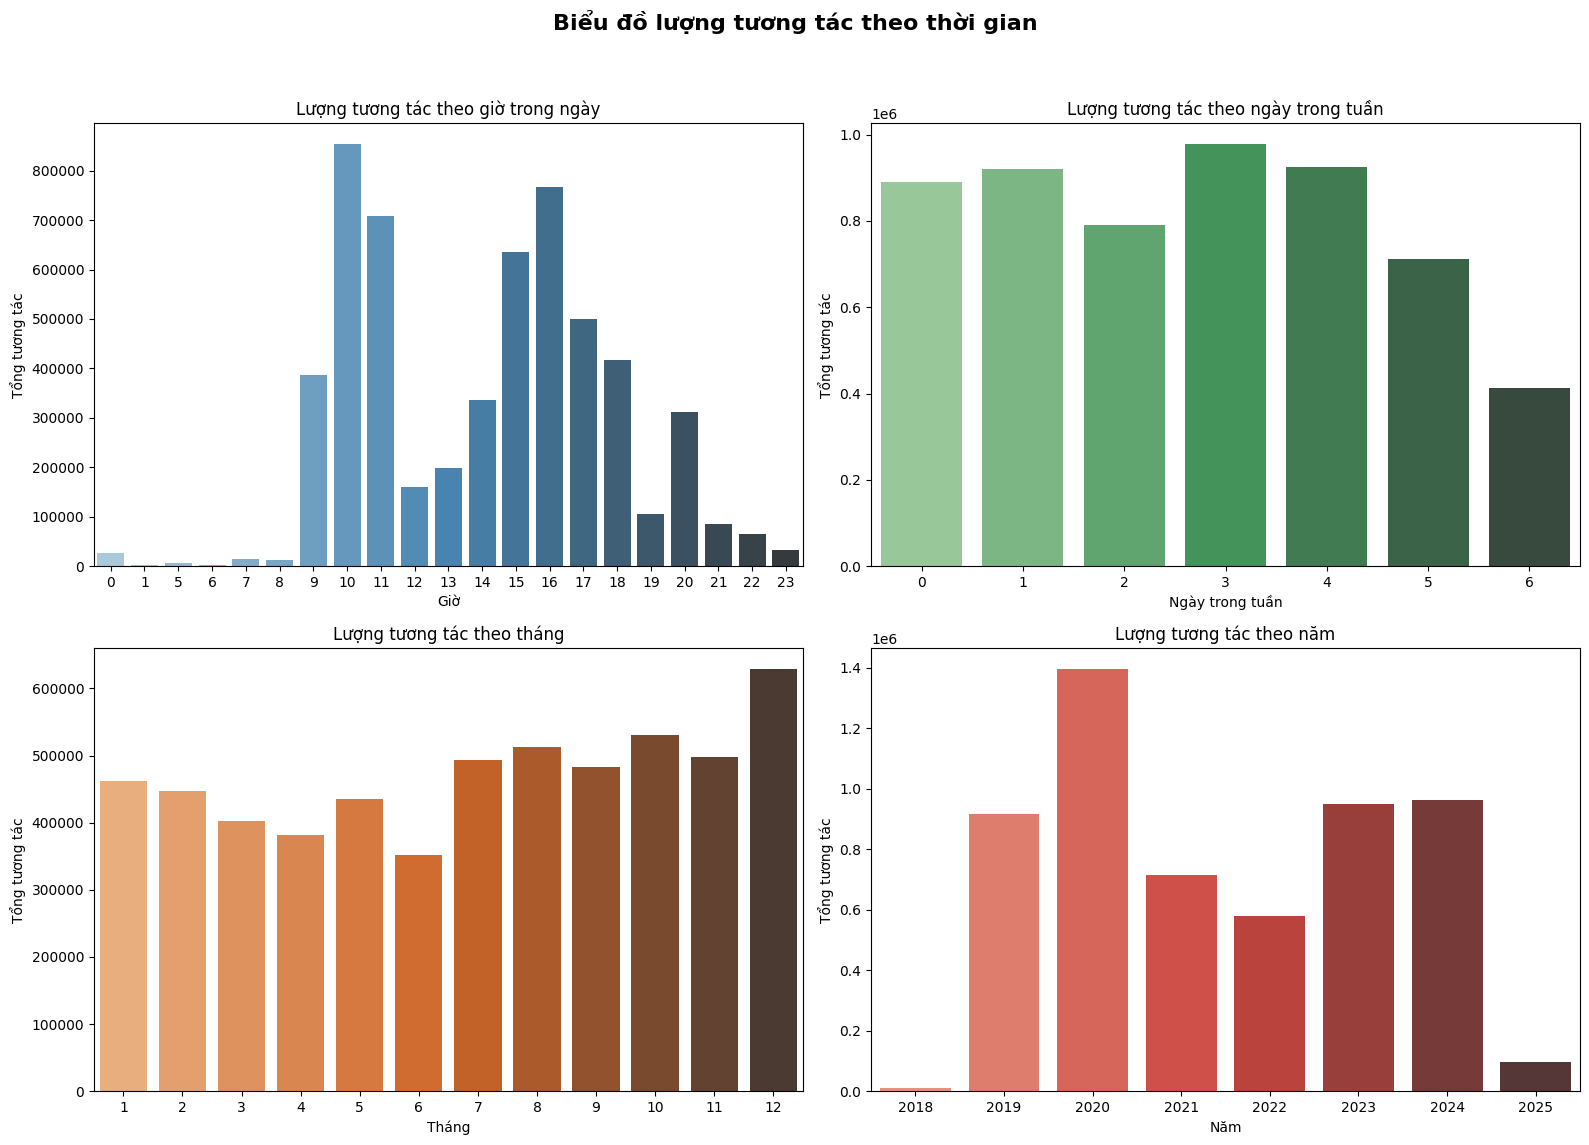

In [ ]:
# Vẽ biểu đồ
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Biểu đồ lượng tương tác theo thời gian", fontsize=16, fontweight="bold")

# 1️⃣ Tương tác theo giờ trong ngày
sns.barplot(x=df_filtered.groupby('hour_vn')[interaction_columns1].sum().index,
            y=df_filtered.groupby('hour_vn')[interaction_columns1].sum().sum(axis=1),
            ax=axes[0, 0], palette="Blues_d")
axes[0, 0].set_title("Lượng tương tác theo giờ trong ngày")
axes[0, 0].set_xlabel("Giờ")
axes[0, 0].set_ylabel("Tổng tương tác")

# 2️⃣ Tương tác theo ngày trong tuần
weekday_labels = ['T2', 'T3', 'T4', 'T5', 'T6', 'T7', 'CN']
sns.barplot(x=df_filtered.groupby('day_of_week_vn')[interaction_columns1].sum().index,
            y=df_filtered.groupby('day_of_week_vn')[interaction_columns1].sum().sum(axis=1),
            ax=axes[0, 1], palette="Greens_d")
axes[0, 1].set_title("Lượng tương tác theo ngày trong tuần")
axes[0, 1].set_xlabel("Ngày trong tuần")
axes[0, 1].set_ylabel("Tổng tương tác")

# 3️⃣ Tương tác theo tháng
sns.barplot(x=df_filtered.groupby('month_vn')[interaction_columns1].sum().index,
            y=df_filtered.groupby('month_vn')[interaction_columns1].sum().sum(axis=1),
            ax=axes[1, 0], palette="Oranges_d")
axes[1, 0].set_title("Lượng tương tác theo tháng")
axes[1, 0].set_xlabel("Tháng")
axes[1, 0].set_ylabel("Tổng tương tác")

# 4️⃣ Tương tác theo năm
sns.barplot(x=df_filtered.groupby('year_vn')[interaction_columns1].sum().index,
            y=df_filtered.groupby('year_vn')[interaction_columns1].sum().sum(axis=1),
            ax=axes[1, 1], palette="Reds_d")
axes[1, 1].set_title("Lượng tương tác theo năm")
axes[1, 1].set_xlabel("Năm")
axes[1, 1].set_ylabel("Tổng tương tác")

# Hiển thị biểu đồ
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

<ipython-input-94-45d8e8bc3266>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = df_filtered.groupby('hour_vn')['likes'].sum().index,


Text(0.5, 1.0, 'Biểu đồ số lượng bài đăng theo lượt thích')

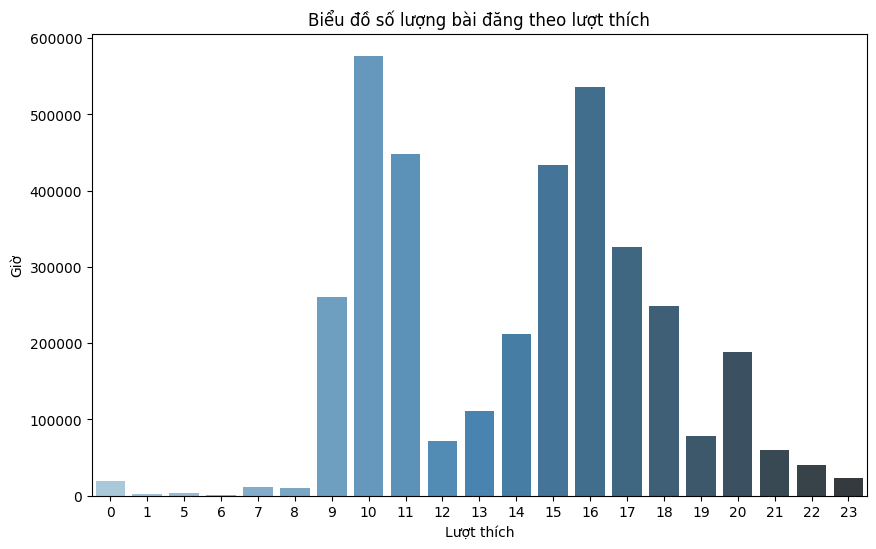

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x = df_filtered.groupby('hour_vn')['likes'].sum().index,
             y= df_filtered.groupby('hour_vn')['likes'].sum().values, palette= 'Blues_d')
plt.xlabel('Lượt thích')
plt.ylabel('Giờ')
plt.title('Biểu đồ số lượng bài đăng theo lượt thích')

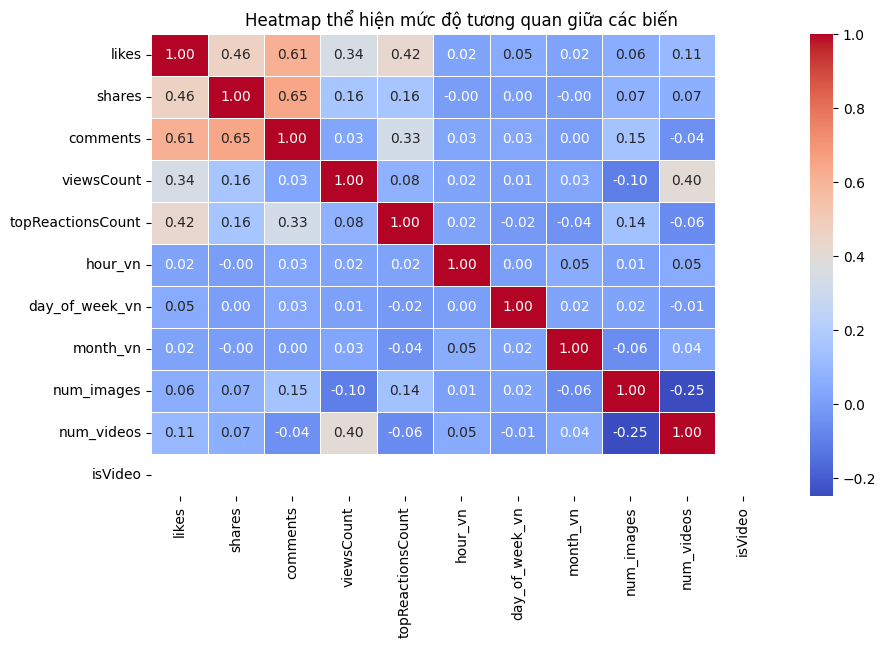

In [ ]:
correlation_columns = ['likes', 'shares', 'comments', 'viewsCount', 'topReactionsCount',
                       'hour_vn', 'day_of_week_vn', 'month_vn', 'num_images', 'num_videos', 'isVideo']

# Tính ma trận tương quan
correlation_matrix = df_filtered[correlation_columns].corr()

# Vẽ Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

plt.title('Heatmap thể hiện mức độ tương quan giữa các biến')
plt.show()

In [ ]:
correlation_columns1 = ['likes', 'shares', 'comments', 'viewsCount', 'topReactionsCount']
correlation_columns2 = ['hour_vn', 'day_of_week_vn', 'month_vn', 'num_images', 'num_videos', 'isVideo']
# Hàm tìm outliers bằng phương pháp IQR
def detect_outliers_iqr(df, column):
  Q1 = df[column].quantile(0.25)
  Q3 = df[column].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR
  outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
  return outliers

# Tìm outliers cho từng cột
detected_outliers = {}
for col in correlation_columns:
    detected_outliers[col] = detect_outliers_iqr(df_filtered, col)
    print(f"Outliers in {col}:\n", detected_outliers[col])




Outliers in likes:
                                                     url  \
17    https://www.facebook.com/DookkiVietnam/posts/p...   
26    https://www.facebook.com/DookkiVietnam/posts/p...   
40    https://www.facebook.com/DookkiVietnam/posts/p...   
41    https://www.facebook.com/DookkiVietnam/posts/p...   
49    https://www.facebook.com/DookkiVietnam/posts/5...   
...                                                 ...   
2612  https://www.facebook.com/DookkiVietnam/posts/p...   
2618  https://www.facebook.com/DookkiVietnam/posts/p...   
2631  https://www.facebook.com/DookkiVietnam/posts/p...   
2669  https://www.facebook.com/DookkiVietnam/posts/p...   
2719  https://www.facebook.com/DookkiVietnam/posts/p...   

                                                   text  \
17    LỄ TẾT DOOKKI CÓ ĐỔI GIÁ KHÔNG???\nCâu trả lời...   
26    DOOKKI x WOORIBANK: CHÀO BẠN MỚI CÙNG QUÀ TẶNG...   
40    6 NĂM VẪN GIỮ NGUYÊN 1 MỨC GIÁ 139.000\n (chưa...   
41    DOOKKI CÓ TRÀ SỮA MIỄN PHÍ TẠ

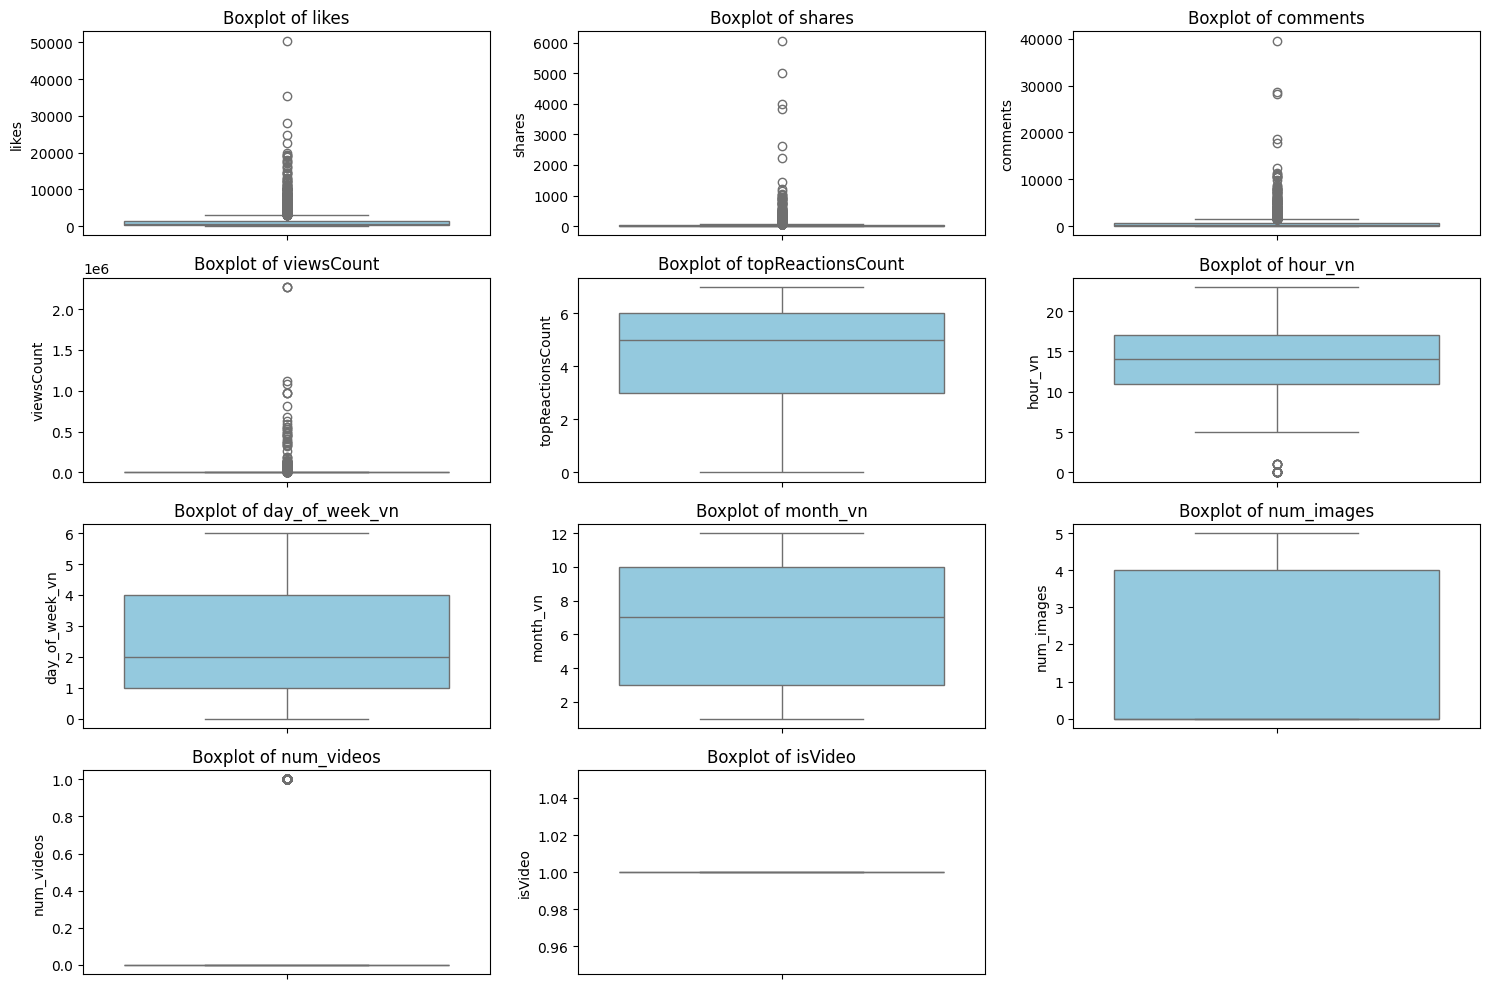

In [ ]:
# Vẽ boxplot để trực quan hóa outliers
plt.figure(figsize=(15, 10))
for i, col in enumerate(correlation_columns, 1):
    plt.subplot(4, 3, i)
    sns.boxplot(y=df_filtered[col], color="skyblue")
    plt.title(f"Boxplot of {col}")
plt.tight_layout()
plt.show()

In [ ]:
with open('/content/vietnamese-stopwords.txt', "r", encoding="utf-8") as f:
  stopwords = f.read().splitlines()



In [ ]:
# Hàm tiền xử lý văn bản
def preprocess_vietnamese_text(text, stopwords):
    if pd.isna(text):
        return ""
    text = text.lower()  # Chuyển về chữ thường
    text = re.sub(r"[^\w\s]", " ", text)
    words = text.split()
    words = [word for word in words if word not in stopwords]  # Loại bỏ stopwords
    return " ".join(words)

# Áp dụng tiền xử lý lên cột 'text'
df_filtered['text_processed'] = df_filtered['text'].apply(lambda x: preprocess_vietnamese_text(x, stopwords))


<ipython-input-100-fa22807cb24e>:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['text_processed'] = df_filtered['text'].apply(lambda x: preprocess_vietnamese_text(x, stopwords))


In [ ]:
df_filtered['comments']

,comments
0,93.0
1,85.0
2,78.0
3,352.0
4,51.0
...,...
2791,4.0
2792,2.0
2793,0.0
2794,0.0


In [ ]:
df_filtered['text_processed']

,text_processed
0,nhả vía khoe lì xì bao tui đi dookki sức chờ d...
1,kèo dookki fen toàn cửa hàng hoạt động trở
2,nóng phát hiện fen vội vàng đi dookki thèm trờ...
3,mí hứa đầu bao tui dookki hên taaa
4,mùng 1 tết mùng 2 tết mẹ mùng 2 tết thầy check...
...,...
2791,buffet tobokki đi hội ghiện món hàn quốc lẩu b...
2792,
2793,
2794,


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Sử dụng danh sách stopwords đã tải từ file
tfidf = TfidfVectorizer(stop_words=list(stopwords), max_features=20)

# Chuyển nội dung sang ma trận TF-IDF
tfidf_matrix = tfidf.fit_transform(df_filtered['text_processed'])

# Lấy danh sách từ khóa quan trọng
feature_names = tfidf.get_feature_names_out()

# Tạo DataFrame với TF-IDF scores
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=feature_names)
tfidf_df['total_engagement'] = df_filtered['likes'] + df_filtered['shares'] + df_filtered['comments']

# Tìm từ khóa liên quan nhất đến lượng tương tác
correlation = tfidf_df.corr()['total_engagement'].sort_values(ascending=False)
print(correlation.head(10))  # Hiển thị 10 từ có tương quan cao nhất với tương tác

/usr/local/lib/python3.11/dist-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['bao', 'bay', 'biến', 'biệt', 'bây', 'bõm', 'bảo', 'bất', 'bẩy', 'bập', 'bắt', 'bội', 'chao', 'chi', 'chia', 'chu', 'chui', 'chuẩn', 'chà', 'chành', 'chí', 'chót', 'chùn', 'chăn', 'chũn', 'chưng', 'chạnh', 'chả', 'chầm', 'chầy', 'chập', 'chắn', 'chẳng', 'chết', 'chốc', 'chừ', 'chừng', 'coi', 'cu', 'cá', 'câu', 'cóc', 'công', 'cạnh', 'cảm', 'cầu', 'cật', 'cắt', 'cổ', 'cụ', 'cục', 'cực', 'da', 'dà', 'dĩ', 'dưng', 'dần', 'dầu', 'dịp', 'dở', 'dụng', 'gian', 'giá', 'giác', 'giời', 'ha', 'hiện', 'hoàn', 'hèn', 'hình', 'hô', 'hầu', 'hậu', 'hẳn', 'hồ', 'hỗ', 'hội', 'hợp', 'hự', 'khói', 'khô', 'khăn', 'khắc', 'khẳng', 'kia', 'kiện', 'kê', 'kì', 'kìa', 'kỳ', 'lai', 'le', 'liên', 'liệt', 'loạt', 'luận', 'luật', 'luốt', 'lình', 'lí', 'lô', 'lý', 'lập', 'lẽ', 'lị', 'lự', 'lực', 'mày', 'mòi', 'mù', 'mạng'

total_engagement    1.000000
thức                0.087190
món                 0.069779
dookki              0.067220
vincom              0.060956
hàn                 0.051377
hà                  0.046085
chi                 0.035378
nhánh               0.027786
nha                 0.018989
Name: total_engagement, dtype: float64


In [ ]:
tfidf_df['total_engagement']

,total_engagement
0,258.0
1,371.0
2,255.0
3,987.0
4,172.0
...,...
2791,16.0
2792,10.0
2793,6.0
2794,6.0


In [ ]:
pip install --upgrade wordcloud pillow

In [ ]:
!ls /usr/share/fonts/truetype/dejavu/DejaVuSans.ttf

ls: cannot access '/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf': No such file or directory


In [ ]:
!sudo apt-get install fonts-dejavu

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  fonts-dejavu-core fonts-dejavu-extra
The following NEW packages will be installed:
  fonts-dejavu fonts-dejavu-core fonts-dejavu-extra
0 upgraded, 3 newly installed, 0 to remove and 20 not upgraded.
Need to get 3,085 kB of archives.
After this operation, 10.7 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 fonts-dejavu-core all 2.37-2build1 [1,041 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/main amd64 fonts-dejavu-extra all 2.37-2build1 [2,041 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-dejavu all 2.37-2build1 [3,192 B]
Fetched 3,085 kB in 0s (11.1 MB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> l

In [ ]:
font_path = "/usr/share/fonts/truetype/liberation/LiberationSans-Regular.ttf"

In [ ]:
!chmod 644 /usr/share/fonts/truetype/dejavu/DejaVuSans.ttf

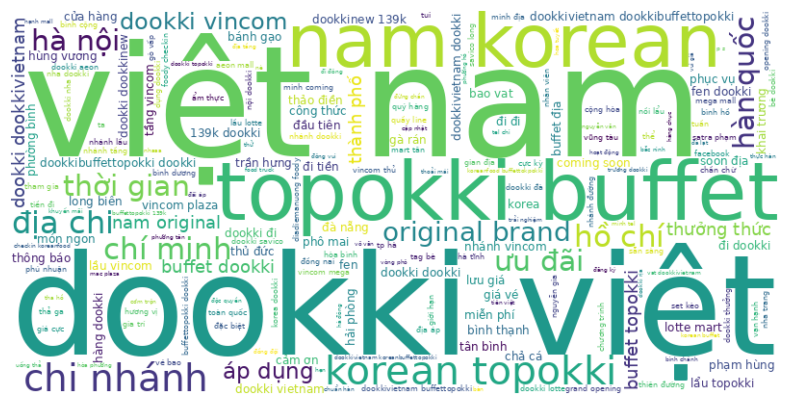

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# 1️⃣ Verify the font path and install the font if needed.
#    - Uncomment and run the following commands if the font is not found:
# !ls /usr/share/fonts/truetype/dejavu/DejaVuSans.ttf
# !sudo apt-get install fonts-dejavu

# 2️⃣ Try a different font
# font_path = "/usr/share/fonts/truetype/liberation/LiberationSans-Regular.ttf"

# 3️⃣ Check font file permissions
# !chmod 644 /usr/share/fonts/truetype/dejavu/DejaVuSans.ttf

# Existing font path
font_path = "/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf"

# Tạo WordCloud
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white",
    font_path=font_path  # Chỉ định font chữ hỗ trợ tiếng Việt
).generate(" ".join(df_filtered["text_processed"]))

# Hiển thị WordCloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

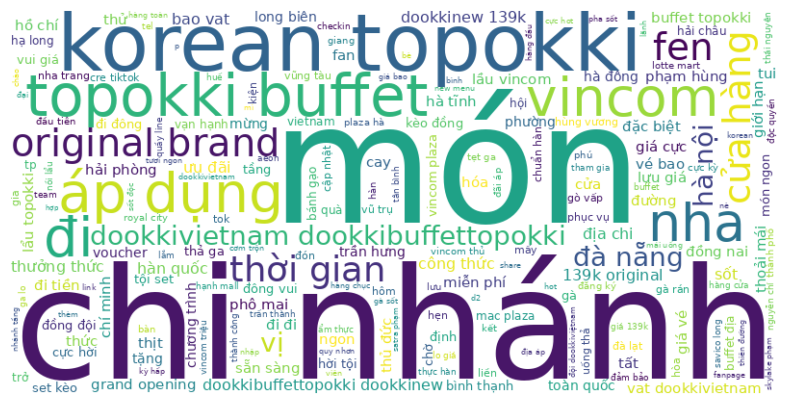

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Danh sách các từ không mong muốn
custom_stopwords = {"việt", "nam", "dookki", "dookki việt", "korea"}

# Chọn top 100 bài viết có tổng tương tác cao nhất
df_top100 = df_filtered.nlargest(100, "total_interactions")  # total_interactions = likes + shares + comments

# Kết hợp toàn bộ nội dung văn bản của top 100 bài viết
top100_text = " ".join(df_top100["text_processed"])

# Lọc các từ không mong muốn
filtered_text = " ".join([
    word for word in top100_text.split() if word.lower() not in custom_stopwords
])

# Tạo WordCloud từ nội dung đã lọc
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white",
    font_path=font_path
).generate(filtered_text)

# Hiển thị WordCloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()


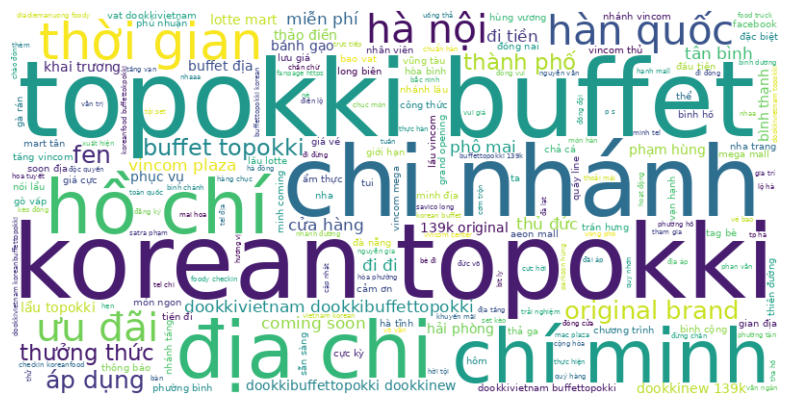

In [ ]:
custom_stopwords = {"việt", "nam", "dookki", "dooki việt", "korea"}

# Lọc nội dung: chỉ giữ lại các từ không có trong danh sách custom_stopwords
filtered_text = " ".join([
    word for word in " ".join(df_filtered["text_processed"]).split()
    if word.lower() not in custom_stopwords
])

# Tạo WordCloud từ nội dung đã lọc
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white",
    font_path=font_path
).generate(filtered_text)

# Hiển thị WordCloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()